<div align="center">

<img src="advertising.jpg" width="500" style="border-radius:15px;">

<h1 style="color:black; font-weight:bold;">
Predicting Sales from Advertising Data Using Linear Regression
</h1>

<h3 style="color:gray;">
Machine Learning Project
</h3>

</div>

<h2 style="color:darkblue;">
Project Workflow
</h2>

1. Import Libraries  
2. Load and Explore the Dataset  
3. Perform Exploratory Data Analysis (EDA)  
4. Analyze Correlations Between Advertising Channels and Sales  
5. Define Features (TV, Radio, Newspaper) and Target Variable (Sales)  
6. Split the Dataset into Training and Testing Sets  
7. Build the Linear Regression Model  
8. Train the Model  
9. Predict Sales Values  
10. Evaluate Model Performance Using R², MAE, and MSE  
11. Identify the Most Effective Advertising Method  
12. Visualize Actual and Predicted Sales Values Using Line Charts  
13. Interpret the Results and Draw Conclusions

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [4]:
df = pd.read_csv("advertising.csv")

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [5]:
df.tail()

,TV,Radio,Newspaper,Sales
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5
199,232.1,8.6,8.7,13.4


In [6]:
df.tail(10)

,TV,Radio,Newspaper,Sales
190,39.5,41.1,5.8,10.8
191,75.5,10.8,6.0,9.9
192,17.2,4.1,31.6,5.9
193,166.8,42.0,3.6,19.6
194,149.7,35.6,6.0,17.3
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5
199,232.1,8.6,8.7,13.4


In [7]:
df.head(10)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,10.6


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [9]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


#### Eksik veri yok, object veri yok, tüm veriler sayısal, encode gerekmiyor

### Korelasyon Analizi

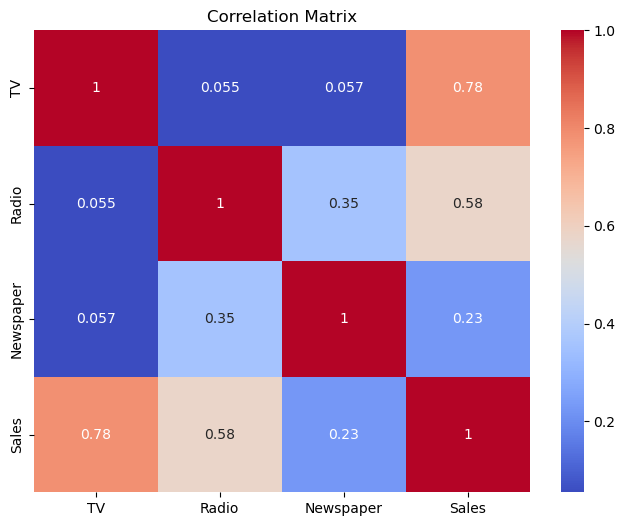

In [10]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

#### Korelasyon matrisi incelendiğinde TV reklamlarının satışlar üzerinde en güçlü etkiye sahip olduğu görülmüştür. Radio reklamları da satışları olumlu yönde etkilerken, Newspaper reklamlarının satışlarla olan ilişkisinin daha zayıf olduğu gözlemlenmiştir. Bu sonuçlar, satış tahmininde TV ve Radio reklam harcamalarının daha önemli değişkenler olduğunu göstermektedir.

In [11]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [13]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
y_pred = lr.predict(X_test)

In [16]:
print(
    "R2 Score:",
    r2_score(y_test, y_pred))

print("MAE:",mean_absolute_error(y_test, y_pred))

print("MSE:",mean_squared_error(y_test, y_pred))

R2 Score: 0.899438024100912
MAE: 1.4607567168117606
MSE: 3.1740973539761055


In [17]:
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_})

coeff_df

,Feature,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


### Korelasyon analizinde TV reklamlarının satışlarla en güçlü ilişkiye sahip olduğu görülmüştür. Ancak regresyon katsayıları incelendiğinde, diğer değişkenler kontrol altında tutulduğunda Radio reklamlarının satışlar üzerinde daha yüksek doğrudan etkiye sahip olduğu belirlenmiştir. Bunun nedeni, korelasyon analizinin değişkenleri tek tek değerlendirmesi; regresyon analizinin ise tüm değişkenleri birlikte değerlendirerek bağımsız etkilerini ölçmesidir.

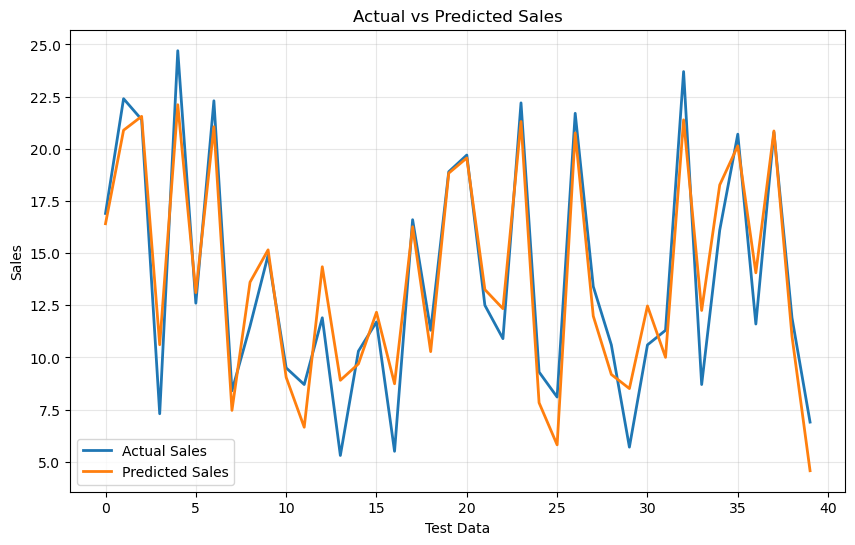

In [18]:
plt.figure(figsize=(10,6))

plt.plot(
    y_test.values,
    label="Actual Sales",
    linewidth=2)

plt.plot(
    y_pred,
    label="Predicted Sales",
    linewidth=2)

plt.title("Actual vs Predicted Sales")

plt.xlabel("Test Data")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

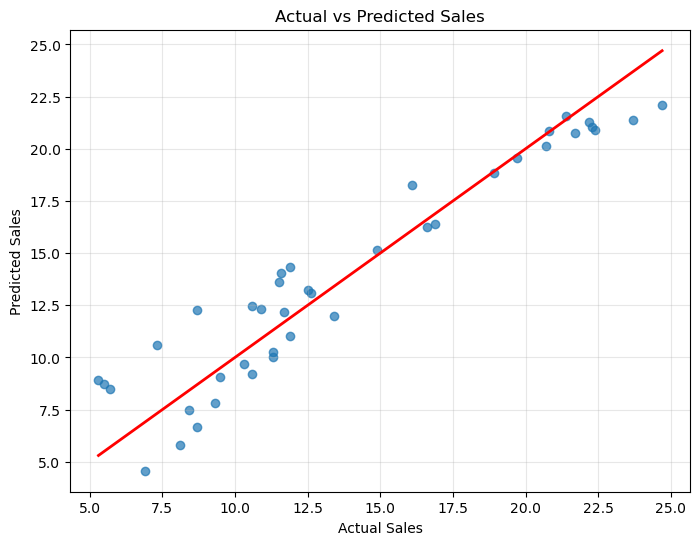

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.grid(alpha=0.3)

plt.show()

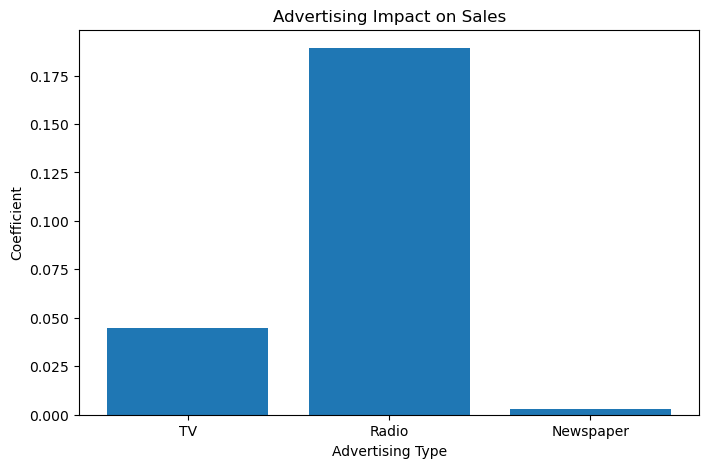

In [21]:
plt.figure(figsize=(8,5))

plt.bar(coeff_df["Feature"],
    coeff_df["Coefficient"])

plt.title("Advertising Impact on Sales")

plt.xlabel("Advertising Type")

plt.ylabel("Coefficient")

plt.show()

In [23]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 1.7815996615334506


In [24]:
print("Train Score:",lr.score(X_train, y_train))
print("Test Score:",lr.score(X_test, y_test))

Train Score: 0.8957008271017817
Test Score: 0.899438024100912


### Linear Regression modeli, eğitim ve test verilerinde birbirine oldukça yakın sonuçlar elde etmiştir. Bu durum modelin yeni veriler üzerinde de başarılı tahminler yapabildiğini ve overfitting problemi göstermediğini ortaya koymaktadır. Yüksek R² değerleri, reklam değişkenlerinin satışlardaki değişimin büyük bölümünü açıkladığını göstermektedir.